In [ ]:
import jax.numpy as jnp
import jax


def control_variate_mc(cst, key, dim, num_samples, known_statistic_g=None):
  r"""
    Computing a Monte Carlo estimate of
      Pr(\abs{\prod_{i=1}^d x_i}\leq c), where (X_i)~N(0, I_d),
    using a control variate (given by function g), with optimal coefficient \gamma
    given by
      \gamma = - Cov(\hat{g}, \hat{f})/Var(\hat{g}) (compute the variance of the linear combination as a function f \gamma, this is
        a second order polynomial with minimum given by the first order condition)
  """
  samples = jax.random.multivariate_normal(key, mean=jnp.zeros(dim), cov=jnp.eye(dim),
                                           shape=(num_samples, ))
  def f(x):
    return (jnp.prod(jnp.abs(x), axis=-1)<=cst)
  statistic_of_interest = f(samples)
  if known_statistic_g:
    evaluated_known_statistic = known_statistic_g(samples, cst)
    mean_g = jnp.mean(evaluated_known_statistic, axis=-1)
    mean_f = jnp.mean(statistic_of_interest, axis=-1)
    gamma = - jnp.mean((statistic_of_interest-mean_f)*(evaluated_known_statistic-mean_g), axis=-1)/jnp.var((evaluated_known_statistic-mean_g), axis=-1)
    return jnp.mean(statistic_of_interest+gamma * evaluated_known_statistic), jnp.var(statistic_of_interest+gamma * evaluated_known_statistic)
  return jnp.mean(statistic_of_interest), jnp.var(statistic_of_interest)
def g1(x, cst):
  """
    Possible choice for the control variates
  """
  return (jnp.abs(x[..., 0])<=cst**1/2)-(jax.scipy.stats.norm.cdf(cst**1/2)-jax.scipy.stats.norm.cdf(-cst**1/2))


cst = 1.0
dim = 2
key = jax.random.PRNGKey(0)
num_samples = 100000
print(control_variate_mc(cst, key, dim, num_samples, g1))


(Array(0.79205465, dtype=float32), Array(0.13872136, dtype=float32))


In [ ]:
csts = jnp.linspace(0.1, 2.0, 100)
vmapped_control_variate_mc = jax.vmap(control_variate_mc, in_axes=(0, None, None, None, None))
res_estimators, res_variance_of_estimators = vmapped_control_variate_mc(csts, key, dim, num_samples, g1)
_, var2 = vmapped_control_variate_mc(csts, key, dim, num_samples, None)

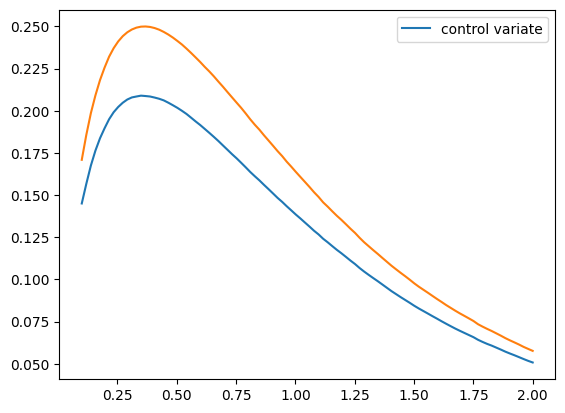

In [ ]:
import matplotlib.pyplot as plt
plt.plot(csts, res_variance_of_estimators, label="control variate")
plt.plot(csts, var2)
plt.legend()

In [ ]:
vmapped_control_variate_mc(csts, key, dim, num_samples, None)

Array([0.64559996, 0.65263   , 0.65944   , 0.66577   , 0.67199   ,
       0.6787    , 0.68474996, 0.69097   , 0.69696   , 0.70272   ,
       0.70844   , 0.71377   , 0.71886   , 0.72428995, 0.72995   ,
       0.73521996, 0.74022   , 0.74491996, 0.74951   , 0.75429   ,
       0.75882995, 0.76348   , 0.76754   , 0.77190995, 0.77593   ,
       0.78016996, 0.78420997, 0.78805   , 0.79188997, 0.79598   ,
       0.79973   , 0.80306   , 0.80680996, 0.81035995, 0.81398   ,
       0.81720996, 0.82071   , 0.82413   , 0.82706   , 0.83006   ,
       0.83318996, 0.83603   , 0.83862996, 0.84125   , 0.84432995,
       0.84704995, 0.84959   , 0.85266995, 0.85567   , 0.85810995,
       0.86057997, 0.86301   , 0.86526   , 0.86754   , 0.86986   ,
       0.87224   , 0.87447995, 0.87684995, 0.87889   , 0.88089997,
       0.88272   , 0.88479996, 0.88676995, 0.88886   , 0.89097   ,
       0.89267   , 0.89438   , 0.89589995, 0.89772   , 0.89945996,
       0.90119   , 0.90283   , 0.90441   , 0.9061    , 0.90764

In [ ]:
res_estimators

Array([0.13102314, 0.16806355, 0.20154846, 0.2318923 , 0.2596948 ,
       0.28628996, 0.31058252, 0.33418167, 0.35648125, 0.37757745,
       0.3976507 , 0.4168243 , 0.43486193, 0.45208007, 0.46907318,
       0.48521268, 0.49984017, 0.5143732 , 0.5285483 , 0.54226726,
       0.5556947 , 0.5681738 , 0.5803699 , 0.5923967 , 0.60367864,
       0.61483675, 0.6255199 , 0.63571507, 0.645519  , 0.655295  ,
       0.6642996 , 0.67347157, 0.6818805 , 0.69024384, 0.6984817 ,
       0.7065033 , 0.71407926, 0.7213415 , 0.72883976, 0.7361207 ,
       0.7426201 , 0.7489007 , 0.75504476, 0.76148427, 0.7675276 ,
       0.77297974, 0.7788481 , 0.7843234 , 0.78963786, 0.79526216,
       0.80035156, 0.80537075, 0.81024474, 0.8149457 , 0.81945336,
       0.8237758 , 0.8280139 , 0.8322231 , 0.83623093, 0.84020984,
       0.84409803, 0.8477732 , 0.8516055 , 0.855192  , 0.8585742 ,
       0.86210394, 0.8651285 , 0.8682791 , 0.8713337 , 0.8741859 ,
       0.8770417 , 0.8798319 , 0.8828804 , 0.8857091 , 0.88860